Random data test:
m = -0.11525463230932649
b = 0.6348724042548727
Original line:
y = 2 x + 1
Custom least squares:
m = 2.0799768445759663
b = 0.9851323351246494
Residuals:
[-0.34464024 -0.42296406 -0.68436307  0.07269383 -0.65509812 -0.65976905
  0.22045162  0.13819558  0.32389787  0.37138052 -0.56332679  0.44467173
 -0.98310339 -0.09757414 -0.20520585 -0.15843838  0.6551797   0.2545632
  0.46678261 -0.24475353  0.15784188 -0.11230261 -0.65905683  0.13465594
  0.19225558  0.36359862  0.81506692  0.09037519  0.83041906 -0.10442403
 -0.98558485  0.45872604  0.96603616  0.59332083  0.72693912  0.02606356
  0.26888296  0.10547279  0.28061666  0.10240441  0.30086011 -0.43218584
 -0.08287011 -0.7119945  -0.5869236   0.24426758  0.50132637  0.07121906
 -0.59946772  0.90497521  0.2934482   0.64148985  0.10507757  0.68880714
  0.26108626  0.15407176 -0.6164323  -0.05082668 -0.86045893 -0.03701415
  0.64469809  0.23608976 -0.769912    0.9266708  -0.28507066 -0.61327462
  0.55412488 -0.61096873  

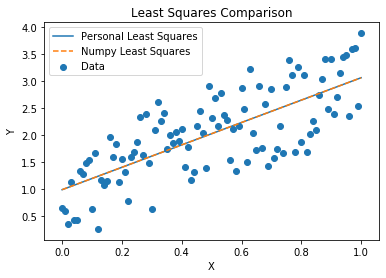

In [9]:
import numpy as np
import matplotlib.pyplot as plt

#Personal least squares method-------------------------------------------------------------------------------------

def least_squares(X, Y):
    A = np.column_stack([X, np.ones(len(X))])
    ATA = A.T @ A
    ATY = A.T @ Y
    m, b = np.linalg.solve(ATA, ATY)
    return m, b

np.random.seed(0)
X_rand = np.random.rand(20)
Y_rand = np.random.rand(20)
X_rand = np.sort(X_rand)
m_rand, b_rand = least_squares(X_rand, Y_rand)

print("Random data test:")
print("m =", m_rand)
print("b =", b_rand)

m_true = 2
b_true = 1

X = np.arange(0, 1.01, 0.01)
noise = np.random.rand(len(X))
sign = np.random.choice([-1, 1], len(X))
noise = noise * sign
Y = m_true * X + b_true + noise
m1, b1 = least_squares(X, Y)
Y_pred1 = m1 * X + b1
residuals = Y - Y_pred1
largest = np.argmax(np.abs(residuals))
smallest = np.argmin(np.abs(residuals))

print("Original line:")
print("y =", m_true, "x +", b_true)
print("Custom least squares:")
print("m =", m1)
print("b =", b1)
print("Residuals:")
print(residuals)
print("Largest residual point:")
print("X =", X[largest], "Y =", Y[largest], "residual =", residuals[largest])
print("Smallest residual point:")
print("X =", X[smallest], "Y =", Y[smallest], "residual =", residuals[smallest])

#Numpy time-----------------------------------------------------------------------------------------------------------

A = np.column_stack([X, np.ones(len(X))])
m2, b2 = np.linalg.lstsq(A, Y, rcond=None)[0]
Y_pred2 = m2 * X + b2

print("Numpy least squares:")
print("m =", m2)
print("b =", b2)
print("Comparison:")
print("Personal method line: y =", m1, "x +", b1)
print("Numpy method line:  y =", m2, "x +", b2)

plt.scatter(X, Y, label="Data")
plt.plot(X, Y_pred1, label="Personal Least Squares")
plt.plot(X, Y_pred2, label="Numpy Least Squares", linestyle="--")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Least Squares Comparison")
plt.legend()
plt.show()